# ENEM 2022–2024 — análise exploratória

**Pergunta que orienta o trabalho:** o desempenho no ENEM é desigual — isso é sabido.
A pergunta útil não é *se* existe desigualdade, é **qual recorte explica mais variação,
e se algum deles se moveu ao longo do tempo**. Um dashboard que só mostra "privada tira
mais que pública" não informa ninguém; um que mostra *onde* a diferença se concentra e
*se ela está aumentando* orienta decisão.

Este notebook responde a isso em cinco perguntas, e cada seção termina com a leitura
escrita do resultado — não só o gráfico. As conclusões daqui definem quais sheets entram
no dashboard, documentados em `TABLEAU_BLUEPRINT.md`.

**Fonte:** microdados oficiais do INEP, edições 2022, 2023 e 2024
([portal](https://www.gov.br/inep/pt-br/acesso-a-informacao/dados-abertos/microdados/enem)).
Todo o tratamento está em `src/` — aqui só analisamos.

## 1. Carga

Trabalhamos sobre os Parquets gerados pelo ETL, não sobre o CSV bruto: os arquivos
originais somam 4,7 GB e 76 colunas, e nada disso cabe confortavelmente num notebook.

Uma decisão importante já foi tomada no ETL e vale repetir aqui, porque ela condiciona
todo número que vem a seguir: **só entram participantes presentes nos dois dias de
prova**. Quem faltou aparece no arquivo original com nota vazia, e tratar esse vazio
como zero — o erro mais comum com este dataset — transformaria "onde as pessoas faltam
mais" em "onde as pessoas vão pior". Com abstenção acima de 30%, o estrago seria grande.

In [1]:
import sys
sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src import config as cfg
from src.features import carregar_edicao

pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

# As tabelas agregadas vêm da BASE COMPLETA (~8 milhões de participantes).
# É delas que sai todo número citado no texto.
agg = {p.stem: pd.read_csv(p) for p in sorted(cfg.DATA_PROCESSED.glob("agg_*.csv"))}
print("tabelas agregadas:", ", ".join(agg))

df23 = carregar_edicao(2023)   # edição completa, usada nos recortes socioeconômicos
print(f"\nENEM 2023 após limpeza: {len(df23):,} participantes | {len(df23.columns)} colunas")

tabelas agregadas: agg_area, agg_faixas, agg_perfil, agg_rede, agg_renda, agg_renda_rede, agg_uf, agg_uf_rede



ENEM 2023 após limpeza: 2,678,232 participantes | 49 colunas


## 2. Panorama: quem sobra depois da limpeza

Antes de qualquer conclusão, é preciso saber sobre quem estamos falando. A tabela abaixo
mostra quanto da base original sobrevive ao filtro de presença, e — mais importante —
qual fração tem a **rede de ensino identificada**.

Esse segundo número é o que mais condiciona a análise. `TP_DEPENDENCIA_ADM_ESC` não é
autodeclarada: vem do pareamento do participante com a base de matrículas do Censo
Escolar, e só existe para quem o INEP identificou como provável concluinte do ensino
médio naquele ano. Quem já terminou o EM há anos não é pareado. Logo, toda comparação
pública × privada deste projeto fala de **concluintes**, não do conjunto de inscritos.

In [2]:
linhas = []
for ano in cfg.ANOS:
    d = carregar_edicao(ano)
    linhas.append({
        "ano": ano,
        "participantes_validos": len(d),
        "com_rede_identificada": d["REDE"].notna().sum(),
        "pct_com_rede": round(100 * d["REDE"].notna().mean(), 1),
        "com_renda_declarada": d["RENDA_GRUPO"].notna().sum() if "RENDA_GRUPO" in d else 0,
        "edicao_completa": bool(d["EDICAO_COMPLETA"].iloc[0]),
    })
    del d

panorama = pd.DataFrame(linhas)
panorama

,ano,participantes_validos,com_rede_identificada,pct_com_rede,com_renda_declarada,edicao_completa
0,2022,2344793,692908,29.6,2344793,True
1,2023,2678232,721423,26.9,2678232,True
2,2024,2990068,1193428,39.9,0,False


Dois fatos saltam da tabela e precisam ser carregados para todas as seções seguintes:

1. **2024 não tem renda.** A coluna vem zerada porque o INEP separou os microdados de
   2024 em duas bases — `PARTICIPANTES` (questionário) e `RESULTADOS` (notas) — sem chave
   que as ligue. O dicionário oficial afirma isso explicitamente sobre `NU_SEQUENCIAL`:
   *"Variável distinta da NU_INSCRICAO disponível na base de Participantes, de modo que
   não é possível utilizá-la para relacionar as duas bases."* Não é limitação do
   pipeline: é anonimização deliberada. Por isso 2024 aparece nos recortes de UF e rede,
   e some dos recortes socioeconômicos.

2. **A cobertura de rede pulou em 2024** — de 26,9% para 39,9%. Isso não é ruído: mudou
   quem está dentro da comparação. Voltaremos a esse ponto na seção 3, porque ele muda a
   interpretação do principal resultado do projeto.

## 3. Insight 1 — o gap público × privado cresceu, mas nem todo o crescimento é real

Este é o número que vai no topo do dashboard, então merece o maior cuidado.

In [3]:
rede = agg["agg_rede"]
piv = rede.pivot(index="ANO", columns="REDE", values="nota_media_geral")
piv["gap"] = (piv["Privada"] - piv["Pública"]).round(1)

cobertura = panorama.set_index("ano")["pct_com_rede"]
piv["cobertura_%"] = cobertura
piv.round(1)

REDE,Privada,Pública,gap,cobertura_%
ANO,,,,
2022,608.5,519.0,89.5,29.6
2023,617.2,519.5,97.7,26.9
2024,614.2,511.0,103.3,39.9


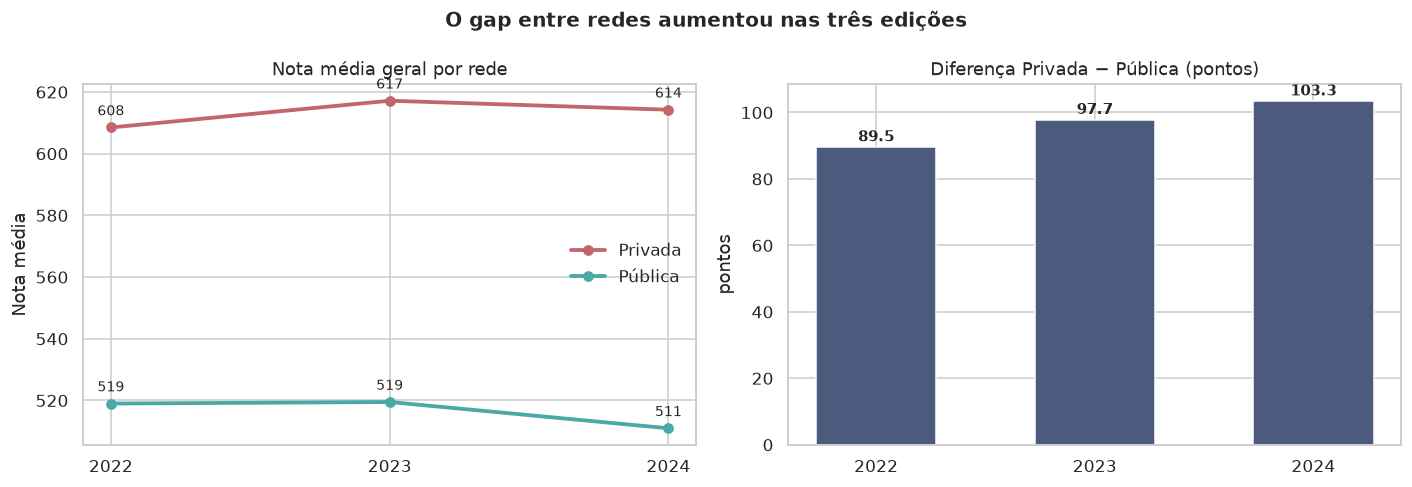

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

for r, cor in [("Privada", "#C1666B"), ("Pública", "#48A9A6")]:
    sub = rede[rede.REDE == r]
    ax1.plot(sub.ANO, sub.nota_media_geral, marker="o", lw=2.5, color=cor, label=r)
    for _, row in sub.iterrows():
        ax1.annotate(f"{row.nota_media_geral:.0f}", (row.ANO, row.nota_media_geral),
                     textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)
ax1.set(title="Nota média geral por rede", xlabel="", ylabel="Nota média")
ax1.set_xticks(list(cfg.ANOS))
ax1.legend(frameon=False)

ax2.bar(piv.index.astype(str), piv["gap"], color="#4C5B7D", width=0.55)
for x, v in zip(piv.index.astype(str), piv["gap"]):
    ax2.annotate(f"{v:.1f}", (x, v), textcoords="offset points", xytext=(0, 4),
                 ha="center", fontsize=10, weight="bold")
ax2.set(title="Diferença Privada − Pública (pontos)", ylabel="pontos")

fig.suptitle("O gap entre redes aumentou nas três edições", fontsize=13, weight="bold")
fig.tight_layout()
fig.savefig(cfg.OUTPUTS_FIGURES / "01_gap_rede.png", bbox_inches="tight")
plt.show()

**Leitura.** O gap cresce de forma monotônica: **89,5 → 97,7 → 103,3 pontos**. A rede
privada praticamente estagnou (608 → 617 → 614) enquanto a pública recuou (519 → 519 →
511). Em três edições, a distância aumentou 15%.

**E agora o cuidado que separa análise de manchete.** A cobertura da variável de rede
saltou de 26,9% para 39,9% em 2024. Um terço a mais de participantes entrou na
comparação, e não entrou aleatoriamente — o pareamento com o Censo Escolar alcança
sobretudo concluintes da rede pública, que é onde o volume está (948 mil participantes
públicos em 2024 contra 507 mil em 2023). Se os participantes recém-incluídos tiverem
perfil médio mais baixo que os já cobertos, **parte do salto de 2024 é composição da
amostra, não queda de desempenho**.

Como o dado disponível não permite separar os dois efeitos, a conclusão honesta é:
*a tendência de 2022 para 2023 é sólida (cobertura estável, 29,6% → 26,9%); o salto de
2024 deve ser lido como limite superior.* No dashboard isso vira uma nota de rodapé no
gráfico, não uma nota escondida no README.

## 4. Insight 2 — Redação é o maior separador entre redes, com folga

Se a diferença entre redes fosse só "escola melhor ensina melhor", ela apareceria de
forma parecida nas cinco áreas. Não é o que acontece.

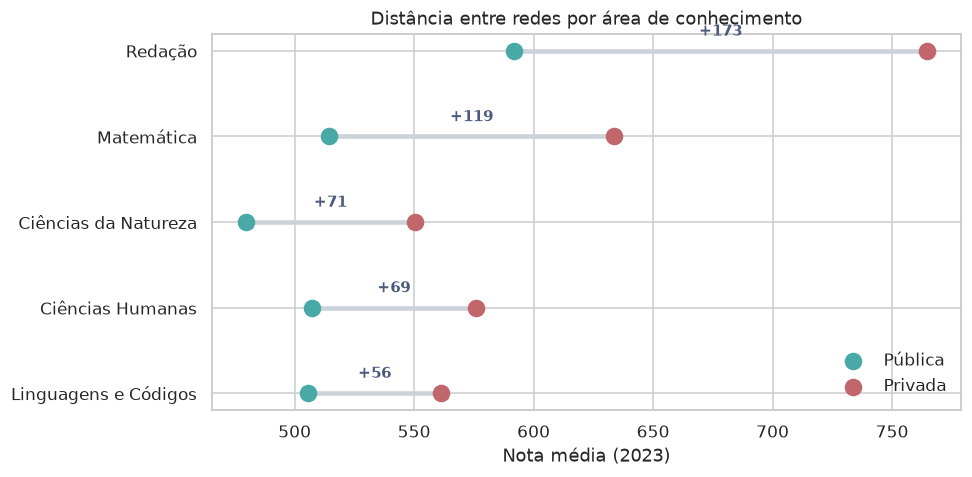

REDE,Privada,Pública,gap
AREA,,,
Linguagens e Códigos,561.3,505.6,55.6
Ciências Humanas,575.9,507.1,68.8
Ciências da Natureza,550.5,479.5,71.0
Matemática,633.6,514.5,119.1
Redação,764.7,591.8,173.0


In [5]:
area = agg["agg_area"]
a23 = area[(area.ANO == 2023) & area.REDE.notna()]

# Média ponderada pelo nº de participantes: as UFs têm tamanhos muito diferentes e a
# média simples entre UFs daria a Roraima o mesmo peso de São Paulo.
nac = (a23.assign(soma=a23.nota_media * a23.n_participantes)
          .groupby(["AREA", "REDE"])
          .apply(lambda g: g.soma.sum() / g.n_participantes.sum(), include_groups=False)
          .unstack())
nac["gap"] = (nac["Privada"] - nac["Pública"]).round(1)
nac = nac.sort_values("gap")

fig, ax = plt.subplots(figsize=(9, 4.5))
y = range(len(nac))
ax.hlines(y, nac["Pública"], nac["Privada"], color="#CBD2D9", lw=3, zorder=1)
ax.scatter(nac["Pública"], y, s=110, color="#48A9A6", zorder=2, label="Pública")
ax.scatter(nac["Privada"], y, s=110, color="#C1666B", zorder=2, label="Privada")
for i, (nome, row) in enumerate(nac.iterrows()):
    ax.annotate(f"+{row.gap:.0f}", ((row["Pública"] + row["Privada"]) / 2, i),
                textcoords="offset points", xytext=(0, 10), ha="center",
                fontsize=10, weight="bold", color="#4C5B7D")
ax.set_yticks(list(y)); ax.set_yticklabels(nac.index)
ax.set(xlabel="Nota média (2023)", title="Distância entre redes por área de conhecimento")
ax.legend(frameon=False, loc="lower right")
fig.tight_layout()
fig.savefig(cfg.OUTPUTS_FIGURES / "02_gap_por_area.png", bbox_inches="tight")
plt.show()

nac.round(1)

**Leitura.** A diferença entre redes vai de **55,6 pontos em Linguagens a 173,0 pontos
em Redação** — mais que o triplo. Matemática vem em segundo, com 119,1.

Isso muda a natureza da conclusão. Linguagens e Ciências Humanas medem sobretudo
repertório acumulado, que a escola influencia mas não monopoliza — leitura fora da sala
de aula compensa parte. Redação e Matemática dependem de **treino explícito, corrigido e
repetido**: alguém precisa ler a redação e devolver com apontamentos, alguém precisa
corrigir a lista de exercícios. É exatamente o insumo que escala mal em turma lotada e
que a rede privada oferece de forma sistemática.

**Implicação prática:** política de redução de desigualdade no ENEM que distribua esforço
igual entre as cinco áreas gasta no lugar errado. O retorno está concentrado em Redação —
onde, além de ser o maior gap, a nota tem escala de 0 a 1000 e é a única corrigida por
humanos, portanto a mais responsiva a intervenção direta.

## 5. Insight 3 — renda tem gradiente quase linear, e Matemática é a mais sensível a ela

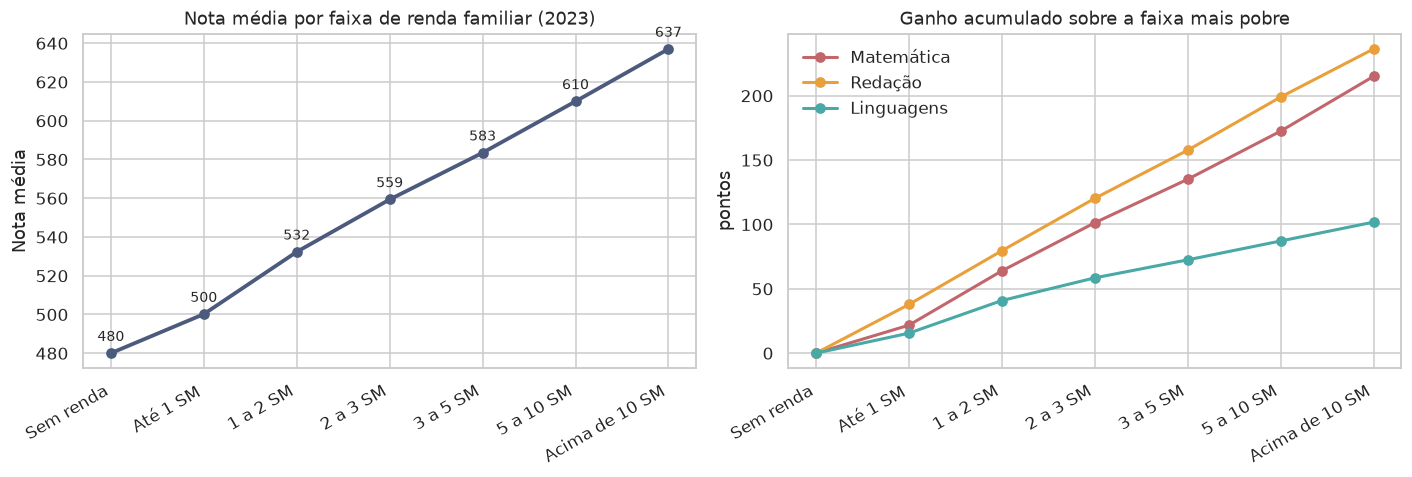

,nota_media_geral,nota_media_mt,nota_media_redacao,n_participantes
RENDA_GRUPO,,,,
Sem renda,480.0,458.5,530.5,155596
Até 1 SM,500.2,480.2,568.3,779095
1 a 2 SM,532.3,522.4,610.0,710313
2 a 3 SM,559.4,559.7,650.7,336719
3 a 5 SM,583.5,593.5,688.1,312145
5 a 10 SM,610.0,630.9,729.4,241350
Acima de 10 SM,637.0,673.4,766.8,143014


In [6]:
renda = agg["agg_renda"]
r23 = renda[renda.ANO == 2023].set_index("RENDA_GRUPO").reindex(cfg.ORDEM_RENDA_GRUPO).dropna(how="all")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

ax1.plot(range(len(r23)), r23.nota_media_geral, marker="o", lw=2.5, color="#4C5B7D")
ax1.set_xticks(range(len(r23)))
ax1.set_xticklabels(r23.index, rotation=30, ha="right")
ax1.set(title="Nota média por faixa de renda familiar (2023)", ylabel="Nota média")
for i, v in enumerate(r23.nota_media_geral):
    ax1.annotate(f"{v:.0f}", (i, v), textcoords="offset points", xytext=(0, 8),
                 ha="center", fontsize=9)

for col, nome, cor in [("nota_media_mt", "Matemática", "#C1666B"),
                       ("nota_media_redacao", "Redação", "#E9A03B"),
                       ("nota_media_lc", "Linguagens", "#48A9A6")]:
    base = r23[col].iloc[0]
    ax2.plot(range(len(r23)), r23[col] - base, marker="o", lw=2, label=nome, color=cor)
ax2.set_xticks(range(len(r23)))
ax2.set_xticklabels(r23.index, rotation=30, ha="right")
ax2.set(title="Ganho acumulado sobre a faixa mais pobre", ylabel="pontos")
ax2.legend(frameon=False)

fig.tight_layout()
fig.savefig(cfg.OUTPUTS_FIGURES / "03_gradiente_renda.png", bbox_inches="tight")
plt.show()

r23[["nota_media_geral", "nota_media_mt", "nota_media_redacao", "n_participantes"]].round(1)

**Leitura.** A nota sobe de forma **monótona e quase linear** em toda a escala de renda:
480,0 na faixa sem renda contra 637,0 acima de 10 salários mínimos — **157 pontos**. Não
há platô nem ponto de saturação: cada degrau de renda ainda compra desempenho no topo da
distribuição, o que é o oposto do que se esperaria se o efeito fosse só "sair da pobreza
extrema".

O painel da direita mostra o detalhe mais acionável: a inclinação **não é igual entre
áreas**. Matemática ganha 215 pontos entre a faixa mais pobre e a mais rica, contra 157
da média geral. Matemática é a área mais sensível a renda de todo o exame — coerente com
o insight anterior, já que é a segunda maior em gap entre redes.

Renda e rede de ensino, porém, estão fortemente correlacionadas: quem estuda em escola
privada tende a ter renda mais alta. As duas seções acima descrevem, em boa medida, o
mesmo fenômeno por dois ângulos. Separá-los exigiria modelagem que este projeto não faz —
por isso o dashboard traz o cruzamento renda × rede (`agg_renda_rede`), que ao menos
permite ao usuário ver os dois eixos simultaneamente em vez de confundi-los.

## 6. Insight 4 — a desigualdade territorial não se moveu em três anos

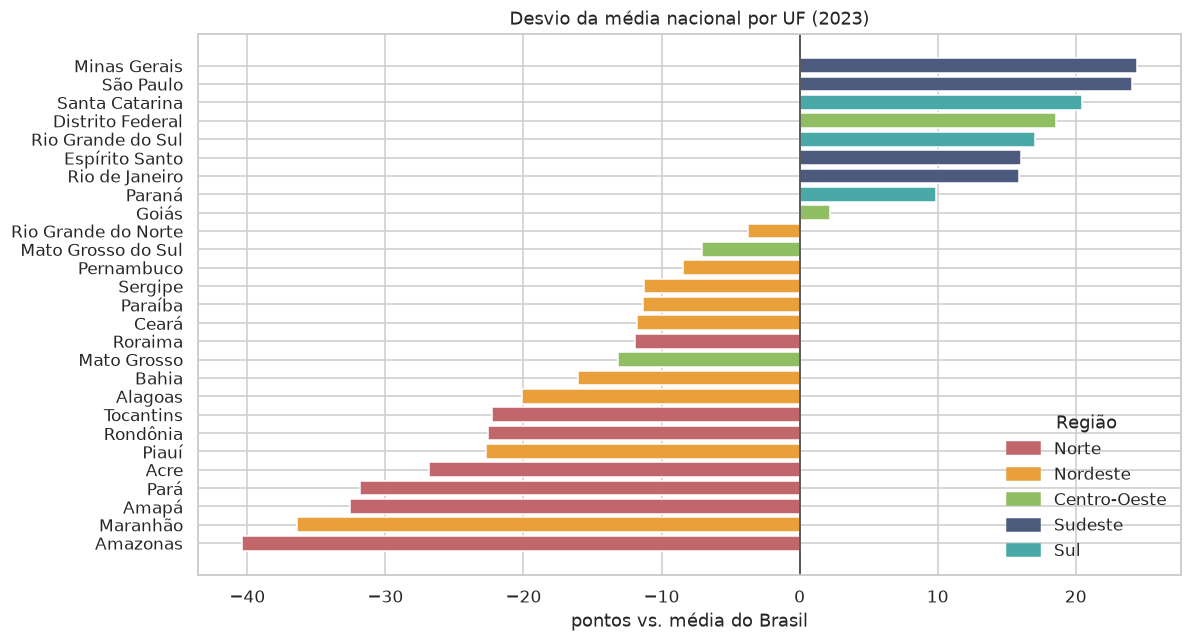

,min,max,std,amplitude
ANO,,,,
2022,503.6,567.1,18.3,63.6
2023,501.5,566.3,19.7,64.8
2024,499.8,565.0,20.0,65.2


In [7]:
uf = agg["agg_uf"]
resumo = uf.groupby("ANO").nota_media_geral.agg(["min", "max", "std"])
resumo["amplitude"] = (resumo["max"] - resumo["min"]).round(1)

fig, ax = plt.subplots(figsize=(11, 6))
ordem = uf[uf.ANO == 2023].sort_values("nota_media_geral").UF_NOME
cores = {"Norte": "#C1666B", "Nordeste": "#E9A03B", "Centro-Oeste": "#8FBF62",
         "Sudeste": "#4C5B7D", "Sul": "#48A9A6"}
u23 = uf[uf.ANO == 2023].set_index("UF_NOME").loc[ordem]
ax.barh(u23.index, u23.desvio_vs_nacional,
        color=[cores[r] for r in u23.REGIAO])
ax.axvline(0, color="#333", lw=1)
ax.set(title="Desvio da média nacional por UF (2023)", xlabel="pontos vs. média do Brasil")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in cores.values()]
ax.legend(handles, cores.keys(), frameon=False, loc="lower right", title="Região")
fig.tight_layout()
fig.savefig(cfg.OUTPUTS_FIGURES / "04_desvio_uf.png", bbox_inches="tight")
plt.show()

resumo.round(1)

**Leitura.** A amplitude entre a melhor e a pior UF é de **63,6 / 64,8 / 65,2 pontos** em
2022, 2023 e 2024. Em três edições, a desigualdade territorial variou 1,6 ponto — ou
seja, **não se moveu**. O desvio-padrão entre UFs conta a mesma história.

O gráfico mostra que a divisão não é aleatória: o bloco abaixo da média nacional é quase
inteiramente Norte e Nordeste (Amazonas, Maranhão, Amapá, Pará e Acre no fundo), e o topo
é Sudeste e Sul. Nenhuma UF trocou de metade entre 2022 e 2024.

**Por que isso importa para o dashboard:** significa que o mapa coroplético deve usar
escala de cor **fixa entre os anos**. Se a escala for recalculada por ano — o
comportamento padrão do Tableau — o mapa vai parecer mudar de um ano para o outro
enquanto os dados dizem o contrário, criando movimento visual onde não há movimento real.
Esse detalhe está registrado no blueprint como parâmetro obrigatório.

## 7. Insight 5 — o custo da desigualdade em termos de acesso ao topo

Média é uma métrica pouco palpável. O que decide vaga em universidade não é a média da
sua rede: é você chegar, ou não, ao topo da distribuição. Então repetimos os dois recortes
anteriores em termos de **probabilidade de alcançar o quintil superior**.

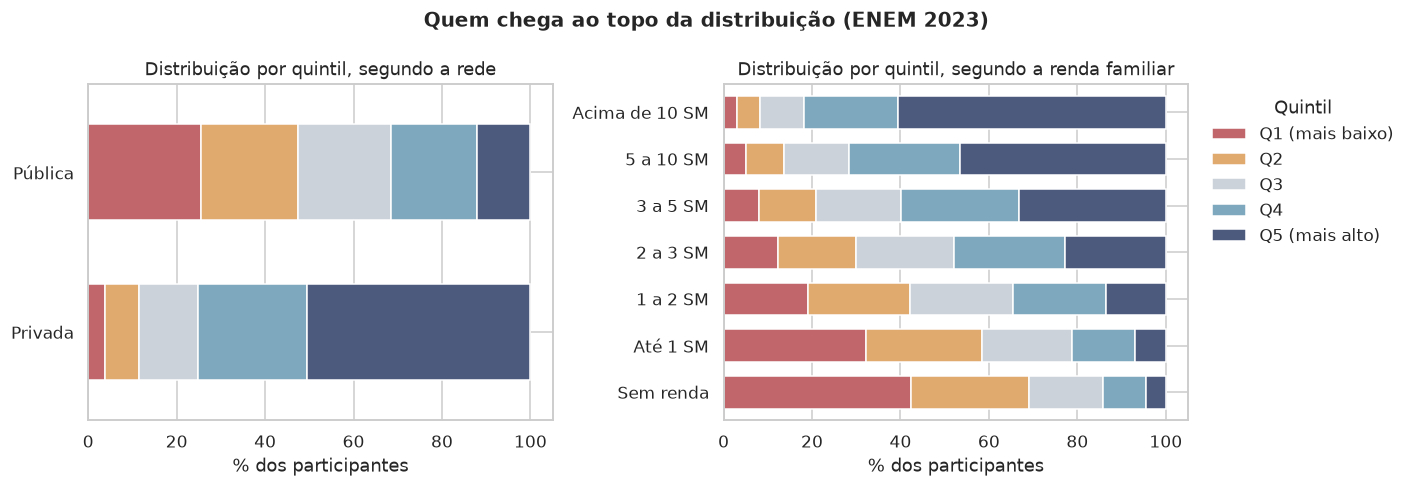

,% no quintil superior,% no quintil inferior
Privada,50.5,3.9
Pública,12.1,25.5
Sem renda,4.4,42.5
Até 1 SM,6.9,32.2
1 a 2 SM,13.5,19.2
2 a 3 SM,22.8,12.2
3 a 5 SM,33.2,8.1
5 a 10 SM,46.5,5.0
Acima de 10 SM,60.5,3.0


In [8]:
quintil_rede = pd.crosstab(df23["REDE"], df23["QUINTIL_DESEMPENHO"], normalize="index") * 100
quintil_renda = pd.crosstab(df23["RENDA_GRUPO"], df23["QUINTIL_DESEMPENHO"], normalize="index") * 100
quintil_renda = quintil_renda.reindex(cfg.ORDEM_RENDA_GRUPO).dropna(how="all")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
paleta = ["#C1666B", "#E0A96D", "#CBD2D9", "#7EA8BE", "#4C5B7D"]

quintil_rede.plot(kind="barh", stacked=True, ax=ax1, color=paleta, width=0.6)
ax1.set(title="Distribuição por quintil, segundo a rede", xlabel="% dos participantes", ylabel="")
ax1.legend().remove()

quintil_renda.plot(kind="barh", stacked=True, ax=ax2, color=paleta, width=0.7)
ax2.set(title="Distribuição por quintil, segundo a renda familiar",
        xlabel="% dos participantes", ylabel="")
ax2.legend(title="Quintil", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)

fig.suptitle("Quem chega ao topo da distribuição (ENEM 2023)", fontsize=13, weight="bold")
fig.tight_layout()
fig.savefig(cfg.OUTPUTS_FIGURES / "05_quintis.png", bbox_inches="tight")
plt.show()

pd.DataFrame({
    "% no quintil superior": pd.concat([
        quintil_rede["Q5 (mais alto)"], quintil_renda["Q5 (mais alto)"]]).round(1),
    "% no quintil inferior": pd.concat([
        quintil_rede["Q1 (mais baixo)"], quintil_renda["Q1 (mais baixo)"]]).round(1),
})

**Leitura.** Traduzida em chance de acesso, a desigualdade fica muito maior do que a
diferença de médias sugeria:

- **Rede:** 50,5% dos alunos de escola privada chegam ao quintil superior, contra 12,1%
  da rede pública — uma razão de **4,2 para 1**. No outro extremo, 25,5% da rede pública
  cai no quintil mais baixo, contra 3,9% da privada.
- **Renda:** 60,5% dos participantes acima de 10 SM chegam ao quintil superior, contra
  4,4% dos sem renda — razão de **13,8 para 1**. E 42,5% do grupo sem renda fica no
  quintil inferior.

Este é o número que deve abrir o dashboard. "A rede privada tira 98 pontos a mais" é
abstrato; "um aluno de escola privada tem 4 vezes mais chance de chegar ao quinto
superior" é a mesma informação numa unidade que qualquer leitor entende — e que expõe
melhor o tamanho real do problema, porque uma diferença modesta de médias vira uma
diferença enorme de acesso quando o que importa é a cauda da distribuição.

## 8. O que vai para o Tableau — e o que deliberadamente não vai

Os cinco insights acima definem os sheets do dashboard, especificados em
`TABLEAU_BLUEPRINT.md`. Vale registrar as escolhas de fonte de dados, porque elas não
são intercambiáveis:

| Uso no dashboard | Fonte | Por quê |
|---|---|---|
| Mapa por UF, KPIs, séries temporais | `agg_*.csv` (base completa) | Números exibidos precisam ser exatos, não estimados |
| Boxplot, histograma, scatter | `enem_amostra.csv` (200 mil linhas) | Precisam de linha por participante; 8 milhões travam o Tableau Public |

A amostra é **estratificada proporcionalmente por UF e autoponderada**: a média por ano
sai a menos de 0,8 ponto da base completa (542,9 vs 543,6 em 2022). Ela é confiável para
forma de distribuição — não para leitura de valor pontual, que é o papel das agregadas.

**O que não entra no dashboard, e por quê:**

- **Renda em 2024** — não existe vínculo com a nota. Melhor ausente que estimado.
- **Nota de corte de curso** — o ENEM aplica pesos por curso no SISU; a média simples que
  usamos aqui não reproduz nenhuma nota de corte real e não deve ser lida como tal.
- **Ranking de escolas** — o código da escola é mascarado pelo INEP quando há menos de 10
  participantes, e ranquear instituições a partir de amostra parcial produziria
  classificação injusta com aparência de rigor.